# **ASID Project: EDA notebook**

Theophilus Owiti
Group 8 Project

**Introduction**

This notebook does EDA on the merged dataset and also an extra step is done for model selection.

## **Import Python imports**

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score


#custom libraries
from utils.stats_module import rices_rule
from utils.plotting import plot_histograms
from utils.model_eval import evaluate_model, utils_confusion_matrix, track_model_performance

## **1. Data Processing**

In this section the following operations are performed:

- Importing the data
- Wrangling the datasets
- Data Preprocessing

### **1.1 Data Wrangling**

In this section we import our data and perform data wrangling and data transformations and clean the data.

In [4]:
#import datasets using pandas

df_1 = pd.read_csv('data/Crop_recommendation.csv')
df_2 = pd.read_csv('data/sensor_Crop_Dataset.csv')

In [5]:
#see top of the data sets
df_1.head(2)

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice


In [6]:
#see top of the data sets
df_2.head(2)

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop,Soil_Type,Variety
0,69.074766,53.954402,88.067625,17.261834,72.941652,4.631301,302.842639,Wheat,Clay,Soft Red
1,107.329352,70.102134,32.081067,21.846116,99.361954,4.761658,94.693847,Tomato,Clay,Beefsteak


In [51]:
df_2["Variety"].unique()

<StringArray>
[  'Soft Red',  'Beefsteak',   'Co 86032',    'Co 0238',      'Sweet',
 'Yukon Gold',   'Hard Red',      'Flint',    'Basmati',   'Co 99004',
       'Dent',       'Roma',     'Russet',    'Jasmine',     'Cherry',
    'Arborio',        'Red',      'Durum']
Length: 18, dtype: str

Filtering the datasets needed for a merge.

In [7]:
#filtering needed dataset
df_1 = df_1[['N','P','K','temperature','humidity','ph','label']]
df_1.head(2)

,N,P,K,temperature,humidity,ph,label
0,90,42,43,20.879744,82.002744,6.502985,rice
1,85,58,41,21.770462,80.319644,7.038096,rice


In [8]:
feature_cols = ['Nitrogen','Phosphorus','Potassium','Temperature','Humidity','pH_Value','Variety','Crop']

In [9]:
df_2 = df_2[feature_cols]
df_2.head(2)

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Variety,Crop
0,69.074766,53.954402,88.067625,17.261834,72.941652,4.631301,Soft Red,Wheat
1,107.329352,70.102134,32.081067,21.846116,99.361954,4.761658,Beefsteak,Tomato


In [10]:
#renaming dataframe 1 columns(df_1)
#df_1.columns = feature_cols

In [11]:
#one last look
df_1.tail(2)

,N,P,K,temperature,humidity,ph,label
2198,117,32,34,26.272418,52.127394,6.758793,coffee
2199,104,18,30,23.603016,60.396475,6.779833,coffee


In [12]:
#get their datashapes
print(f"Data Frame 1 shape: {df_1.shape}")
print(f"Data Frame 2 shape: {df_2.shape}")

Data Frame 1 shape: (2200, 7)
Data Frame 2 shape: (20000, 8)


Concatinating the dataset

In [13]:
#concatination of df1 and df2
#sensor_df = pd.concat([df_2], axis=0)
sensor_df = df_2

sensor_df.head(10)


,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Variety,Crop
0,69.074766,53.954402,88.067625,17.261834,72.941652,4.631301,Soft Red,Wheat
1,107.329352,70.102134,32.081067,21.846116,99.361954,4.761658,Beefsteak,Tomato
2,130.634624,67.204533,28.294252,33.246895,81.506836,6.566007,Co 86032,Sugarcane
3,15.169301,87.493181,14.336679,14.396289,59.274465,6.296297,Co 0238,Sugarcane
4,21.881965,89.269712,38.833885,16.773218,51.191584,8.268274,Sweet,Maize
5,19.660304,6.616578,62.189607,34.067791,42.672884,6.442318,Beefsteak,Tomato
6,30.311986,36.287921,69.749442,33.444551,48.140219,6.067489,Yukon Gold,Potato
7,33.710764,42.909834,71.629966,12.607354,68.966061,5.640770,Sweet,Maize
8,70.295205,56.440554,86.625145,16.437203,89.183316,6.447732,Hard Red,Wheat
9,65.330526,22.768994,91.222638,34.779166,81.824903,8.233027,Flint,Maize


In [14]:
#make the categories small letters
sensor_df["Crop"] = sensor_df["Crop"].str.lower()

In [15]:
#dataset shape
print(f"Data Frame shape: {sensor_df.shape}")

Data Frame shape: (20000, 8)


**Count the number of classes for each crop category**

This section shows you how many examples are available in each category given the crop's given class.

In [16]:
sensor_df.groupby("Crop").count()

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Variety
Crop,,,,,,,
maize,3352,3352,3352,3352,3352,3352,3352
potato,3362,3362,3362,3362,3362,3362,3362
rice,3268,3268,3268,3268,3268,3268,3268
sugarcane,3284,3284,3284,3284,3284,3284,3284
tomato,3344,3344,3344,3344,3344,3344,3344
wheat,3390,3390,3390,3390,3390,3390,3390


Check for the crops that are at least above 3000

In [17]:
sensor_df['Crop'].value_counts()[sensor_df['Crop'].value_counts() > 3000]

Crop
wheat        3390
potato       3362
maize        3352
tomato       3344
sugarcane    3284
rice         3268
Name: count, dtype: int64

Create a new dataframe to take in the crops found above

In [18]:
sensor_df_filtered = sensor_df[sensor_df['Crop'].isin(["maize","wheat","rice","potato","tomato","sugarcane"])]
sensor_df_filtered.count()

Nitrogen       20000
Phosphorus     20000
Potassium      20000
Temperature    20000
Humidity       20000
pH_Value       20000
Variety        20000
Crop           20000
dtype: int64

In [19]:
sensor_df_filtered["Crop"].value_counts()

Crop
wheat        3390
potato       3362
maize        3352
tomato       3344
sugarcane    3284
rice         3268
Name: count, dtype: int64

In [20]:
sensor_df_filtered.groupby("Crop").count()

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Variety
Crop,,,,,,,
maize,3352,3352,3352,3352,3352,3352,3352
potato,3362,3362,3362,3362,3362,3362,3362
rice,3268,3268,3268,3268,3268,3268,3268
sugarcane,3284,3284,3284,3284,3284,3284,3284
tomato,3344,3344,3344,3344,3344,3344,3344
wheat,3390,3390,3390,3390,3390,3390,3390


Transform the dataset

In [21]:
from sklearn.preprocessing import LabelEncoder
le_variety = LabelEncoder()

sensor_df_filtered['Variety'] = le_variety.fit_transform(sensor_df_filtered['Variety'])

Checking the mean and how many are below the mean

In [22]:
sensor_df_filtered.groupby("Crop").aggregate("mean") #ignore variety

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Variety
Crop,,,,,,,
maize,78.525586,47.009656,54.845544,27.436142,65.019653,6.514409,10.724642
potato,75.494087,47.622115,54.796005,27.744447,64.582532,6.500091,14.311422
rice,76.098774,47.776682,55.482046,27.355261,64.380960,6.511000,3.905753
sugarcane,77.957123,46.910803,55.291079,27.203927,64.915154,6.520950,5.004872
tomato,76.449443,47.097117,55.010942,27.580944,65.522739,6.466600,6.064294
wheat,78.749702,48.459424,55.558955,27.199470,64.954671,6.464854,10.926549


**Getting outliers using Z-Score**

In [23]:
import numpy as np
import pandas as pd

# List of numeric columns to check
cols = ['Nitrogen','Phosphorus','Potassium','Temperature','Humidity','pH_Value','Variety']

results = {}

for col in cols:
    #Z-score method
    z_scores = (sensor_df_filtered[col] - sensor_df_filtered[col].mean()) / sensor_df_filtered[col].std()
    z_outliers = (np.abs(z_scores) > 3).sum()
    
    #IQR method
    Q1 = sensor_df_filtered[col].quantile(0.25)
    Q3 = sensor_df_filtered[col].quantile(0.75)
    IQR = Q3 - Q1
    iqr_outliers = ((sensor_df_filtered[col] < Q1 - 1.5*IQR) | 
                    (sensor_df_filtered[col] > Q3 + 1.5*IQR)).sum()
    
    # Store results
    results[col] = {"Z-score_outliers": z_outliers, "IQR_outliers": iqr_outliers}

# Display nicely
outlier_df = pd.DataFrame(results).T
print(outlier_df)


             Z-score_outliers  IQR_outliers
Nitrogen                    0             0
Phosphorus                  0             0
Potassium                   0             0
Temperature                 0             0
Humidity                    0             0
pH_Value                    0             0
Variety                     0             0


**Check for Correlation**

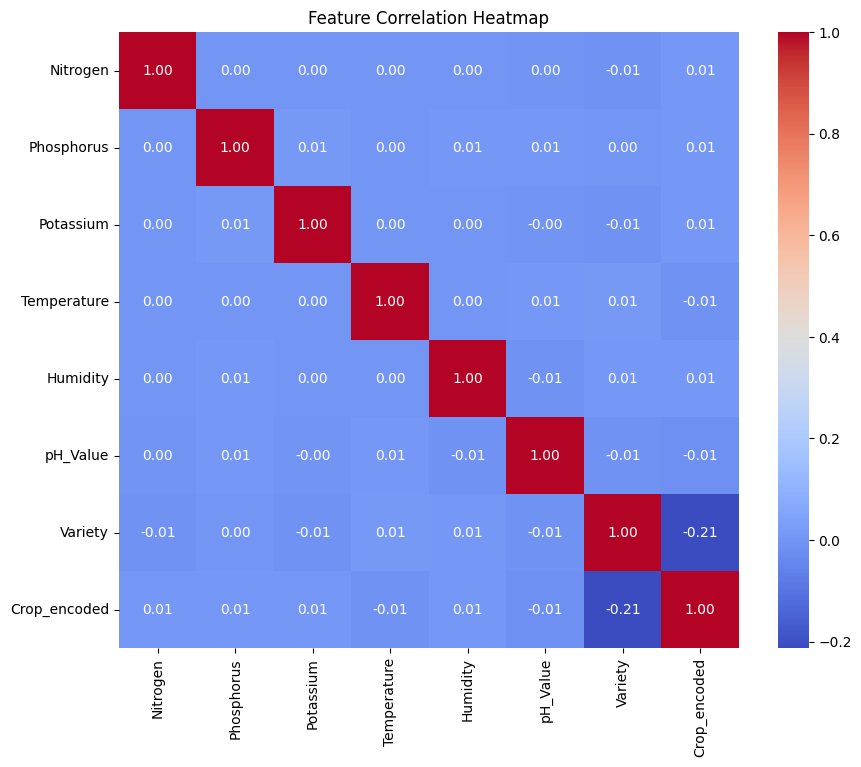

: 

: 

In [ ]:
# Encode the Crop label to numbers to check correlation
df_corr = sensor_df_filtered.copy()
df_corr['Crop_encoded'] = df_corr['Crop'].astype('category').cat.codes

# Plot the heatmap
# Use numeric_only=True to automatically ignore the string columns
plt.figure(figsize=(10, 8))
sns.heatmap(df_corr.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.show()

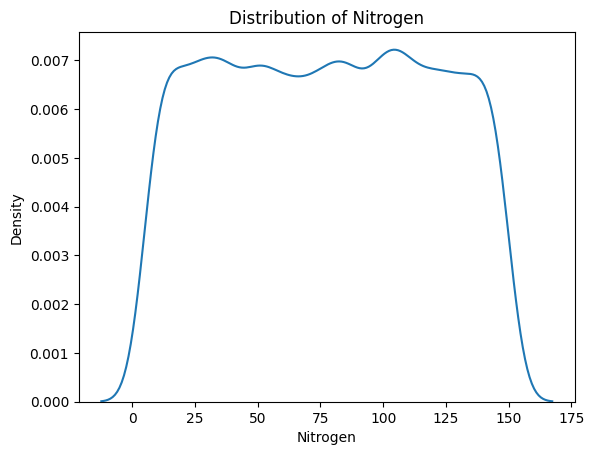

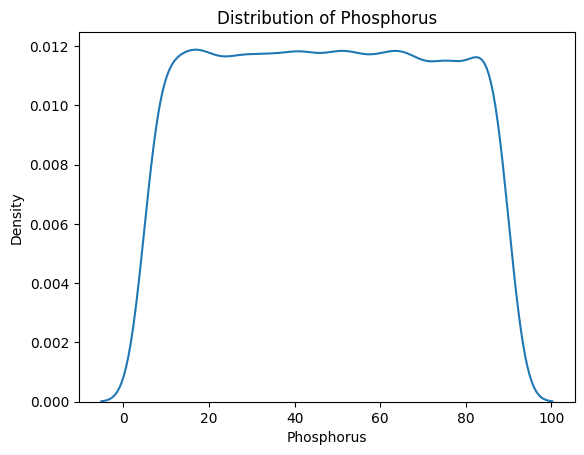

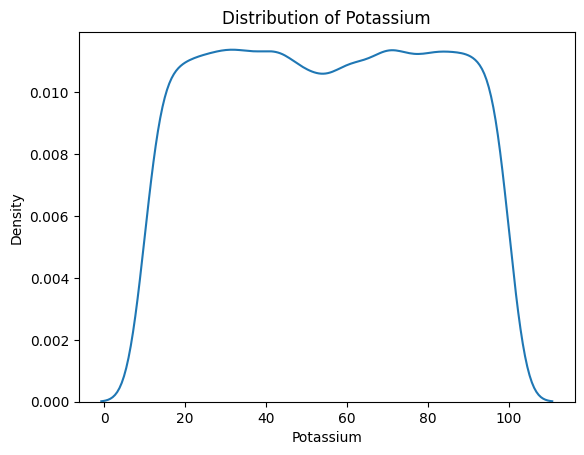

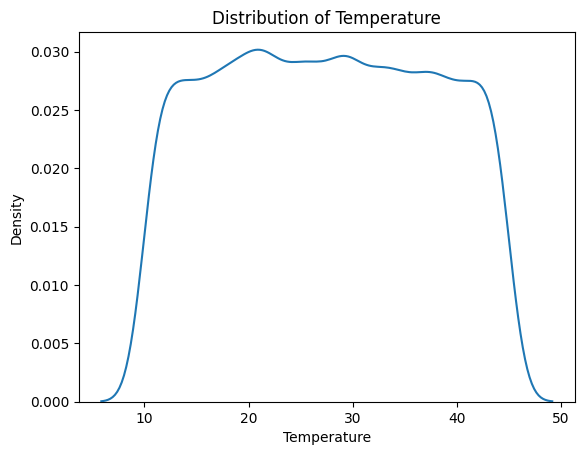

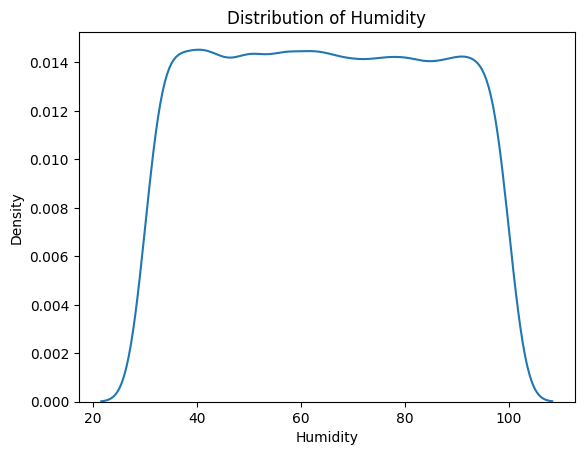

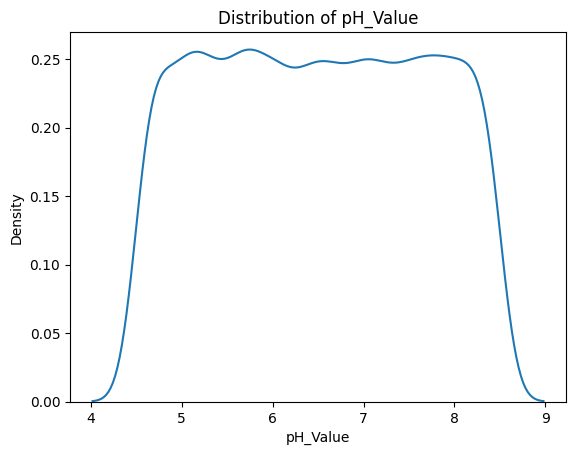

TypeError: The x variable is categorical, but one of ['numeric', 'datetime'] is required

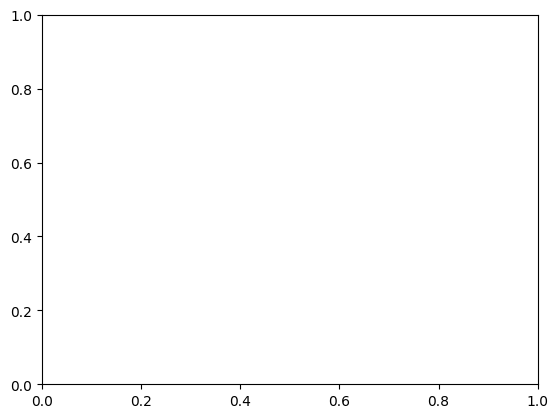

: 

: 

In [ ]:
# Check means of features by the source dataset (if you have an identifier)
# If you don't have a 'source' column, you can check the histograms for 'double peaks'
for col in feature_cols[:-1]: # exclude 'Crop'
    sns.kdeplot(sensor_df[col])
    plt.title(f"Distribution of {col}")
    plt.show()

**Multicolinearity**

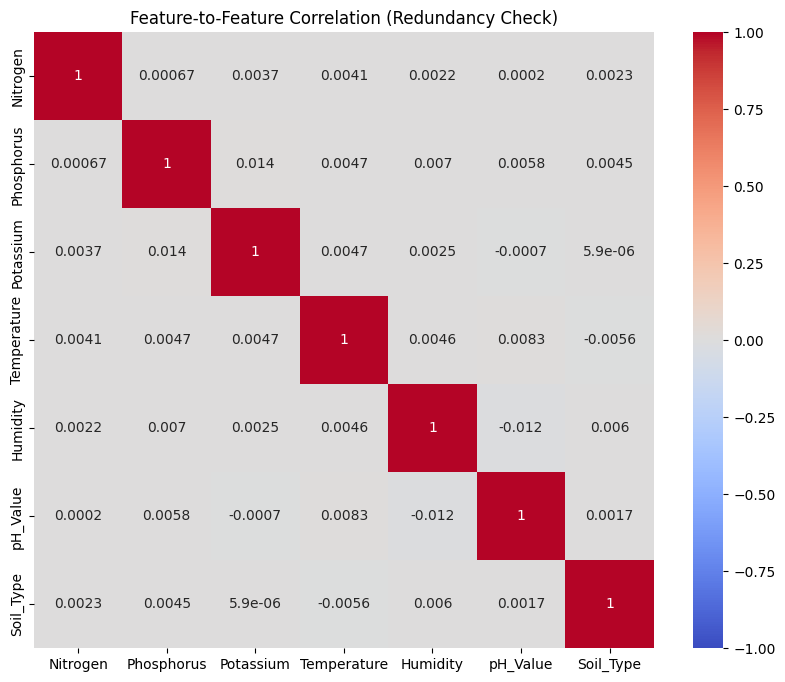

: 

: 

In [ ]:
# Drop the target and check correlations among predictors
features_only = sensor_df_filtered.drop(columns=['Crop'])
correlation_matrix = features_only.corr()

# Visualize only the feature relationships (excluding Crop)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Feature-to-Feature Correlation (Redundancy Check)")
plt.show()

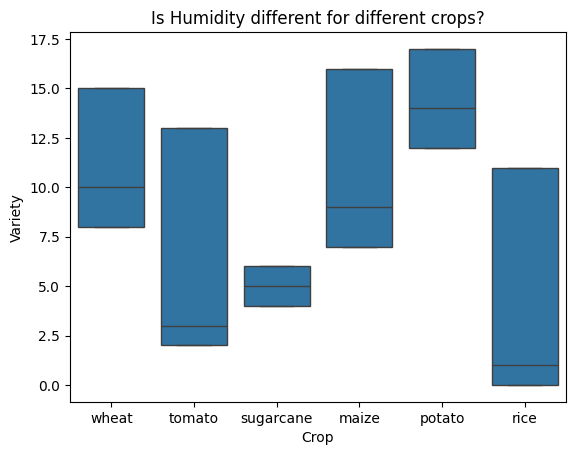

: 

: 

In [ ]:
# Check the distributions of one feature across all 6 classes
# This will show you if, for example, 'Rice' has a different 'Humidity' than 'Tomato'
sns.boxplot(data=sensor_df_filtered, x='Crop', y='Variety')
plt.title("Is Humidity different for different crops?")
plt.show()

The above indicates this is a data problem where all boxes/distributions are at the same level. The sensor does not change across different crops. Hence data merge becomes the primary issue.

## **1.2 Data Processing**

In this section we focus on preparing the data for analysis and modeling, improving its quality and usability.

**1.2.0 Changing the labels in target**

In [25]:
crop_categories = sensor_df_filtered["Crop"].unique().tolist()
crop_categories_map = {}

for i in range(len(crop_categories)):
    crop_categories_map[crop_categories[i]] = i

print(crop_categories_map)

{'wheat': 0, 'tomato': 1, 'sugarcane': 2, 'maize': 3, 'potato': 4, 'rice': 5}


In [26]:
#using custom map create above
sensor_df_filtered["Crop"] = sensor_df_filtered["Crop"].map(crop_categories_map)

In [27]:
#check
sensor_df_filtered.tail(3)

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Variety,Crop
19997,25.001919,19.140862,32.719994,29.001299,55.231845,8.230164,10,0
19998,74.396171,42.100129,20.669153,22.349399,84.369830,7.878051,15,0
19999,41.503429,30.633619,38.022107,15.916907,68.865347,5.044274,14,4


**1.2.1 Checking for missing values and handling them**

In [28]:
#get missing values in every column
sensor_df.isna().sum()

Nitrogen       0
Phosphorus     0
Potassium      0
Temperature    0
Humidity       0
pH_Value       0
Variety        0
Crop           0
dtype: int64

**1.2.2 Checking for data distributions per column using histogram**

This is important to see the skewness of our dataset.

Since we expect some of our data to be skewed we the formula below to choose bin size, Rice's Rule:

let $n$ be number of observations

$$bins = \sqrt[3]{n} \times 2$$

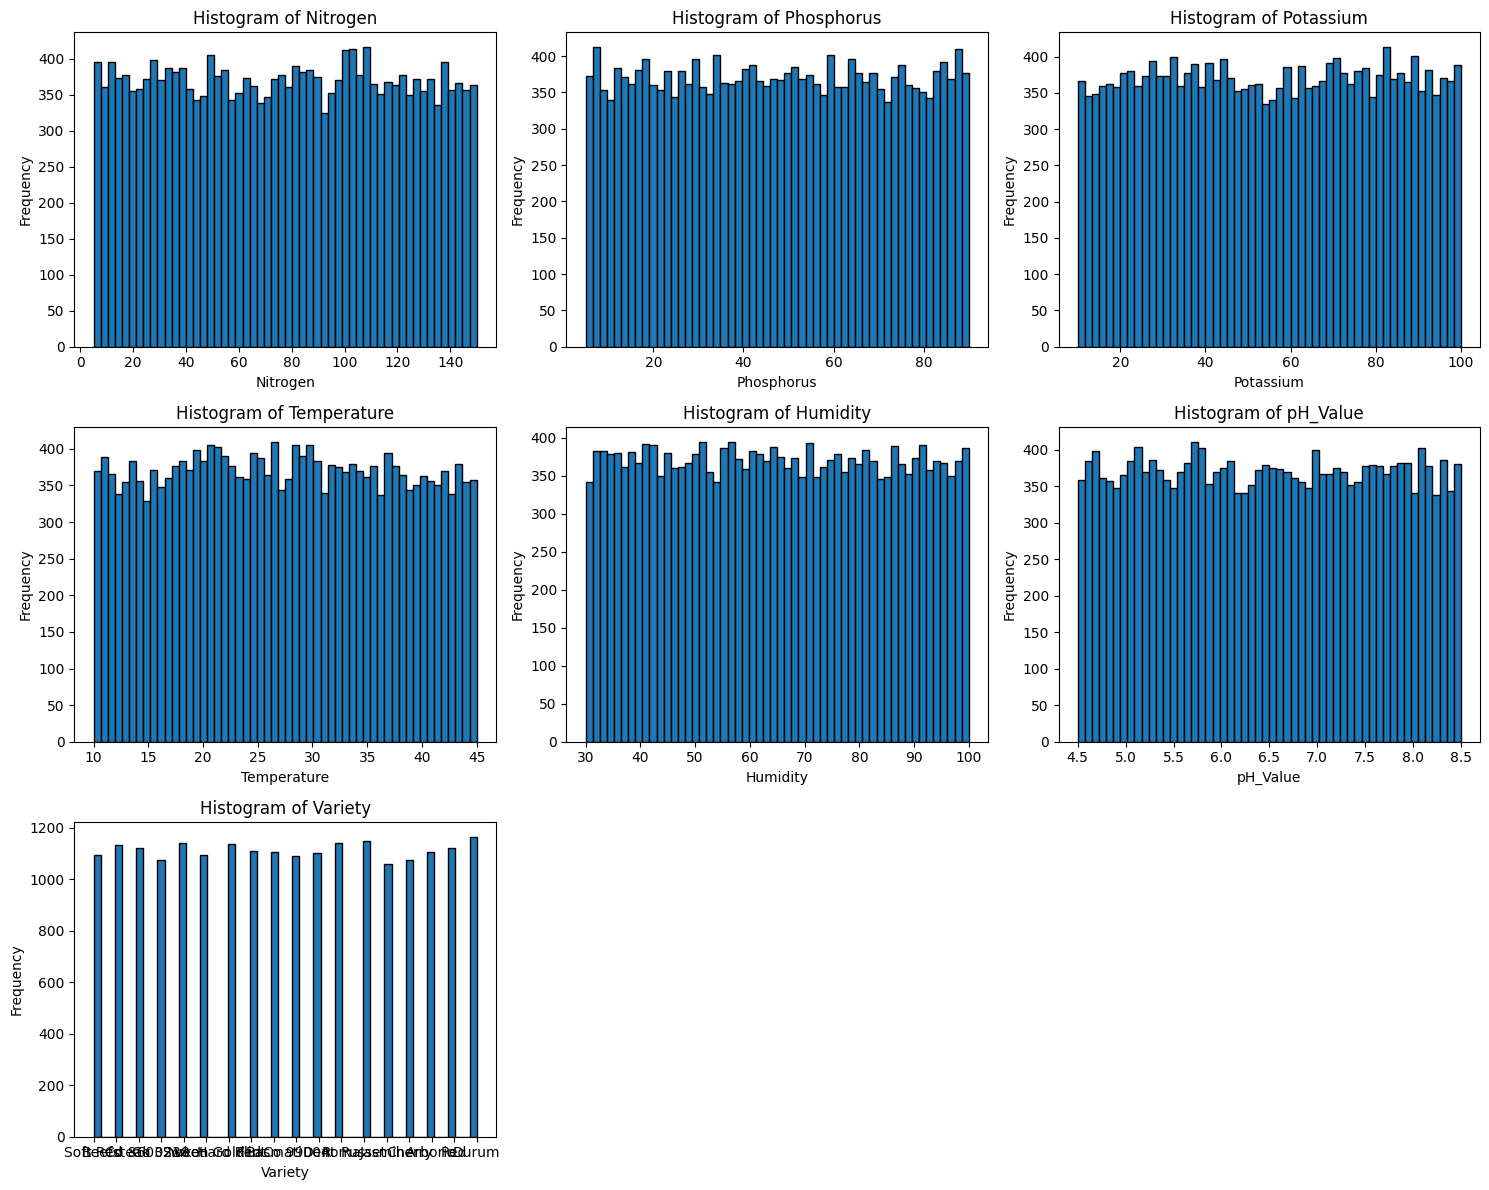

In [29]:
x_features = feature_cols[0:len(feature_cols)-1]
plot_histograms(features=x_features, df=sensor_df)

**1.2.3 Splitting features and performing transformations**

In [30]:
X = sensor_df_filtered.drop(columns=["Crop"])
y = sensor_df_filtered["Crop"]

feature_names = X.columns.tolist()
feature_names

#if using one dataframe default to this
#feature_names = ["Nitrogen","Phosphorus","Potassium","Temperature","Humidity","pH_Value","Rainfall"]
#X = X[feature_names]
#X.columns.tolist


['Nitrogen',
 'Phosphorus',
 'Potassium',
 'Temperature',
 'Humidity',
 'pH_Value',
 'Variety']

In [31]:
#splitting the data to train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


### Track Model Performance

In [32]:
import time

In [33]:
# Global list to store comparison data
model_comparison_data = []

**CatBoost Model**

In [ ]:
cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="MultiClass",
    verbose=False,
    random_state=42
)

start_train = time.time()
cat_model.fit(X_train, y_train)
end_train = time.time() - start_train

y_pred_cat = cat_model.predict(X_test)

cat_model_result = track_model_performance(cat_model, "CatBoost Classifier", X_test, y_test, y_pred_cat, end_train)

model_comparison_data.append(cat_model_result)



In [35]:
evaluate_model(y_test, y_pred_cat, "CatBoost")


CatBoost Results
Accuracy: 1.0
Macro Precision: 1.0
Macro Recall: 1.0
Macro F1: 1.0
Weighted Precision: 1.0
Weighted Recall: 1.0
Weighted F1: 1.0

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       678
           1       1.00      1.00      1.00       669
           2       1.00      1.00      1.00       657
           3       1.00      1.00      1.00       670
           4       1.00      1.00      1.00       672
           5       1.00      1.00      1.00       654

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



**XGBoot\ Lightgbm**

Log transfrom is applied

In [36]:
skewed_features = ["Phosphorus", "Potassium","Humidity"]

X_train_log = X_train.copy()
X_test_log = X_test.copy()

for col in skewed_features:
    X_train_log[col] = np.log1p(X_train_log[col])
    X_test_log[col] = np.log1p(X_test_log[col])


In [39]:
#xgboost
xgb_model = XGBClassifier(
    objective="multi:softmax",
    num_class=y.nunique(),
    eval_metric="mlogloss",
    random_state=42
)





start_train = time.time()
xgb_model.fit(X_train_log, y_train)
end_train = time.time() - start_train

y_pred_xgb = xgb_model.predict(X_test_log)

xgboost_model_result = track_model_performance(xgb_model, "XGBoost Classifier", X_test, y_test, y_pred_xgb, end_train)

model_comparison_data.append(xgboost_model_result)


evaluate_model(y_test, y_pred_xgb, "XGBoost")



XGBoost Results
Accuracy: 1.0
Macro Precision: 1.0
Macro Recall: 1.0
Macro F1: 1.0
Weighted Precision: 1.0
Weighted Recall: 1.0
Weighted F1: 1.0

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       678
           1       1.00      1.00      1.00       669
           2       1.00      1.00      1.00       657
           3       1.00      1.00      1.00       670
           4       1.00      1.00      1.00       672
           5       1.00      1.00      1.00       654

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



In [41]:
#light GBM
lgbm_model = LGBMClassifier(
    objective="multiclass",
    random_state=42
)

start_time = time.time()

lgbm_model.fit(X_train_log, y_train)

end_time = time.time() - start_time

y_pred_lgbm = lgbm_model.predict(X_test_log)

lgbm_model_result = track_model_performance(lgbm_model, "Light GBM",X_test, y_test, y_pred_lgbm, end_time)

model_comparison_data.append(lgbm_model_result)


evaluate_model(y_test, y_pred_lgbm, "LightGBM")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000339 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1548
[LightGBM] [Info] Number of data points in the train set: 16000, number of used features: 7
[LightGBM] [Info] Start training from score -1.774902
[LightGBM] [Info] Start training from score -1.788639
[LightGBM] [Info] Start training from score -1.806746
[LightGBM] [Info] Start training from score -1.786026
[LightGBM] [Info] Start training from score -1.783048
[LightGBM] [Info] Start training from score -1.811707
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [W

**Random Forest**

In [42]:
#Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

str_time = time.time()
rf_model.fit(X_train_log, y_train)
training_end_time = time.time() - str_time

y_pred_rf = rf_model.predict(X_test_log)

rf_model_results = track_model_performance(rf_model, "Random Forest Model", X_test, y_test, y_pred_rf, training_end_time)

model_comparison_data.append(rf_model_results)


evaluate_model(y_test, y_pred_rf, "Random Forest")



Random Forest Results
Accuracy: 1.0
Macro Precision: 1.0
Macro Recall: 1.0
Macro F1: 1.0
Weighted Precision: 1.0
Weighted Recall: 1.0
Weighted F1: 1.0

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       678
           1       1.00      1.00      1.00       669
           2       1.00      1.00      1.00       657
           3       1.00      1.00      1.00       670
           4       1.00      1.00      1.00       672
           5       1.00      1.00      1.00       654

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



**Feature Importance**

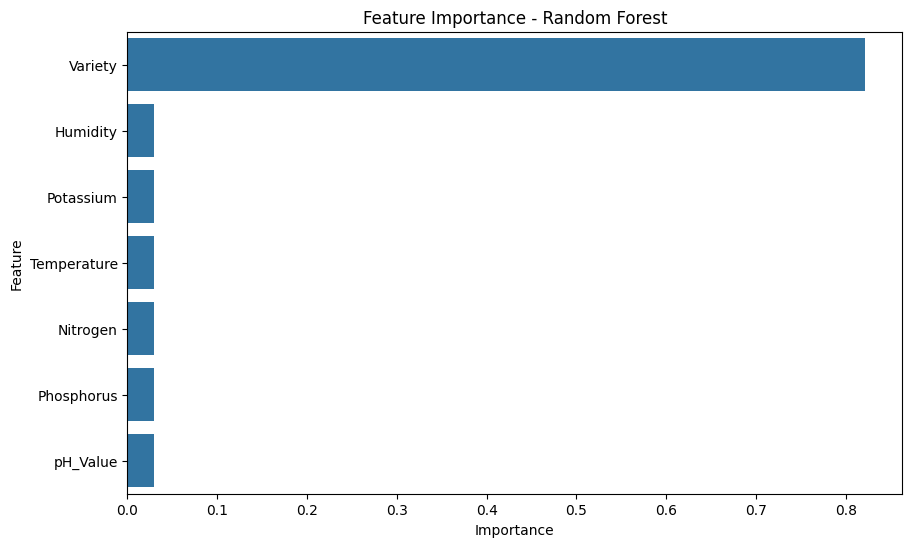

In [43]:
# Extract feature importance from your Random Forest model
importances = rf_model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot the importance
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x='Importance', y='Feature')
plt.title("Feature Importance - Random Forest")
plt.show()

**Multinomial Logistic Regression**

In [44]:
preprocessor_lr = Pipeline(steps=[
    ("power", PowerTransformer(method="yeo-johnson")),
    ("scaler", StandardScaler())
])


In [46]:
lr_pipeline = Pipeline(
    steps=[ ("preprocessing", preprocessor_lr), 
           ("classifier", LogisticRegression(solver="lbfgs", max_iter=1000, n_jobs=-1 )) ])

s_time = time.time()
lr_pipeline.fit(X_train, y_train)
e_time = time.time() - s_time

y_pred_lr = lr_pipeline.predict(X_test)

lr_model_res = track_model_performance(lr_pipeline, "Multinomial Logistic Regression", X_test, y_test, y_pred_lr, e_time)

model_comparison_data.append(lr_model_res)

evaluate_model(y_test, y_pred_lr, "Logistic Regression")



Logistic Regression Results
Accuracy: 0.355
Macro Precision: 0.37654946261969574
Macro Recall: 0.35620535633275807
Macro F1: 0.34145898412698644
Weighted Precision: 0.3746243993265905
Weighted Recall: 0.355
Weighted F1: 0.3401270811782221

Classification Report
              precision    recall  f1-score   support

           0       0.27      0.24      0.25       678
           1       0.00      0.00      0.00       669
           2       0.84      0.36      0.51       657
           3       0.27      0.20      0.23       670
           4       0.42      0.68      0.52       672
           5       0.46      0.66      0.54       654

    accuracy                           0.35      4000
   macro avg       0.38      0.36      0.34      4000
weighted avg       0.37      0.35      0.34      4000



c:\Users\linco\Documents\projects\AISD project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


**Deep Learning  - MLP**

In [47]:
pt = PowerTransformer(method="yeo-johnson")
scaler = StandardScaler()

X_train_dl = scaler.fit_transform(pt.fit_transform(X_train))
X_test_dl = scaler.transform(pt.transform(X_test))


In [48]:
import tensorflow as tf
from keras import layers, models

model = models.Sequential([
    layers.Dense(64, activation="relu", input_shape=(X_train_dl.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dense(y.nunique(), activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


strart_train = time.time()
history = model.fit(
    X_train_dl, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=0
)
end_training = time.time() - strart_train



# Evaluate loss and accuracy
test_loss, test_acc = model.evaluate(X_test_dl, y_test, verbose=0)
print("Neural Network Accuracy:", test_acc)

# Get predicted probabilities
y_pred_probs = model.predict(X_test_dl)


# Convert probabilities to predicted class
import numpy as np
y_pred_nn = np.argmax(y_pred_probs, axis=1)


mlp_model_result = track_model_performance(model, "Neural Net (TensorFlow)",X_test_dl, y_test, y_pred_nn, end_training)

model_comparison_data.append(mlp_model_result)

# Evaluate using your metrics
evaluate_model(y_test, y_pred_nn, "TensorFlow Neural Network")


c:\Users\linco\Documents\projects\AISD project\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Neural Network Accuracy: 1.0
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 773us/step


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 705us/step

TensorFlow Neural Network Results
Accuracy: 1.0
Macro Precision: 1.0
Macro Recall: 1.0
Macro F1: 1.0
Weighted Precision: 1.0
Weighted Recall: 1.0
Weighted F1: 1.0

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       678
           1       1.00      1.00      1.00       669
           2       1.00      1.00      1.00       657
           3       1.00      1.00      1.00       670
           4       1.00      1.00      1.00       672
           5       1.00      1.00      1.00       654

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



In [49]:
print("Number of classes:", y.nunique())
print(y.value_counts())


Number of classes: 6
Crop
0    3390
4    3362
3    3352
1    3344
2    3284
5    3268
Name: count, dtype: int64


## **Model Comparison**

In [50]:
# Convert the collected data into a DataFrame
comparison_df = pd.DataFrame(model_comparison_data)

# Display the table
print("Model Selection Comparison Table:")
display(comparison_df.sort_values(by="F1-Score", ascending=False))

# Optional: Highlight the best model based on F1-Score
best_model = comparison_df.iloc[comparison_df['F1-Score'].idxmax()]['Model']
print(f"\nRecommended Model based on F1-Score: {best_model}")

Model Selection Comparison Table:


,Model,Size (MB),Training Time (s),Latency (s/sample),Precision,Recall,F1-Score
0,CatBoost Classifier,1.7598,3.6632,0.000001,1.0000,1.000,1.0000
1,CatBoost Classifier,1.7598,3.6632,0.000001,1.0000,1.000,1.0000
2,XGBoost Classifier,0.4798,0.2819,0.000001,1.0000,1.000,1.0000
3,Light GBM,1.4594,0.4350,0.000003,1.0000,1.000,1.0000
4,Random Forest Model,78.9195,5.7940,0.000017,1.0000,1.000,1.0000
6,Neural Net (TensorFlow),0.0625,25.6838,0.000034,1.0000,1.000,1.0000
5,Multinomial Logistic Regression,0.0023,0.1194,0.000001,0.3746,0.355,0.3401



Recommended Model based on F1-Score: CatBoost Classifier
